# Electricity Demand Modelling




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Used to scale the data and keep model validation in time order
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Regression models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Victoria Electricity Demand Analysis

## Data loading and cleaning


In [2]:
# Find all monthly Victoria CSV files and keep them in date order.
vic_folder = Path("VIC")
vic_files = sorted(vic_folder.glob("*.csv"))

print("Number of VIC files:", len(vic_files))
print(vic_files[:5])


Number of VIC files: 67
[PosixPath('VIC/PRICE_AND_DEMAND_201801_VIC1.csv'), PosixPath('VIC/PRICE_AND_DEMAND_201802_VIC1.csv'), PosixPath('VIC/PRICE_AND_DEMAND_201803_VIC1.csv'), PosixPath('VIC/PRICE_AND_DEMAND_201804_VIC1.csv'), PosixPath('VIC/PRICE_AND_DEMAND_201805_VIC1.csv')]


In [3]:
# Check one source file first so the columns and data types are understood before combining everything.
sample_vic = pd.read_csv(vic_files[0])

display(sample_vic.head())

print("Shape:", sample_vic.shape)
print("\nColumns:")
print(sample_vic.columns.tolist())

print("\nData types:")
print(sample_vic.dtypes)


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2018/01/01 00:30:00,4251.18,92.46,TRADE
1,VIC1,2018/01/01 01:00:00,4092.53,87.62,TRADE
2,VIC1,2018/01/01 01:30:00,3958.95,73.08,TRADE
3,VIC1,2018/01/01 02:00:00,3785.27,70.18,TRADE
4,VIC1,2018/01/01 02:30:00,3673.72,67.43,TRADE


Shape: (1488, 5)

Columns:
['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']

Data types:
REGION                str
SETTLEMENTDATE        str
TOTALDEMAND       float64
RRP               float64
PERIODTYPE            str
dtype: object


In [4]:
# Combine all monthly files into one Victoria dataframe.
vic_dataframes = []

for file in vic_files:
    df = pd.read_csv(file)
    vic_dataframes.append(df)

vic = pd.concat(vic_dataframes, ignore_index=True)

print("Combined VIC shape:", vic.shape)
display(vic.head())


Combined VIC shape: (249744, 5)


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2018/01/01 00:30:00,4251.18,92.46,TRADE
1,VIC1,2018/01/01 01:00:00,4092.53,87.62,TRADE
2,VIC1,2018/01/01 01:30:00,3958.95,73.08,TRADE
3,VIC1,2018/01/01 02:00:00,3785.27,70.18,TRADE
4,VIC1,2018/01/01 02:30:00,3673.72,67.43,TRADE


In [5]:
# Convert settlement time to datetime and sort the records from earliest to latest.
vic["SETTLEMENTDATE"] = pd.to_datetime(vic["SETTLEMENTDATE"])
vic = vic.sort_values("SETTLEMENTDATE").reset_index(drop=True)

print(vic.dtypes)


REGION                       str
SETTLEMENTDATE    datetime64[us]
TOTALDEMAND              float64
RRP                      float64
PERIODTYPE                   str
dtype: object


In [6]:
# Check data quality before modelling.
# REGION and PERIODTYPE are also checked because constant columns do not add predictive information within one state.
print("Shape:", vic.shape)

print("\nMissing values:")
print(vic.isnull().sum())

print("\nDuplicate rows:")
print(vic.duplicated().sum())

print("\nUnique REGION values:")
print(vic["REGION"].value_counts())

print("\nUnique PERIODTYPE values:")
print(vic["PERIODTYPE"].value_counts())


Shape: (249744, 5)

Missing values:
REGION            0
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
PERIODTYPE        0
dtype: int64

Duplicate rows:
0

Unique REGION values:
REGION
VIC1    249744
Name: count, dtype: int64

Unique PERIODTYPE values:
PERIODTYPE
TRADE    249744
Name: count, dtype: int64


In [7]:
# Review the range and distribution of electricity demand and price values.
display(vic[["TOTALDEMAND", "RRP"]].describe())


,TOTALDEMAND,RRP
count,249744.000000,249744.000000
mean,4772.841348,95.015165
std,914.006635,217.139423
min,1976.530000,-1000.000000
25%,4123.655000,19.170000
50%,4653.565000,70.855000
75%,5308.510000,126.192500
max,9507.260000,15100.000000


In [8]:
# Check whether the time gap between observations stays consistent across the dataset.
time_differences = vic["SETTLEMENTDATE"].diff()

print(time_differences.value_counts().head(10))


SETTLEMENTDATE
0 days 00:05:00    184032
0 days 00:30:00     65711
Name: count, dtype: int64


In [9]:
# Locate the point where the source data changes recording frequency.
vic["TIME_DIFF"] = vic["SETTLEMENTDATE"].diff()

change_points = vic[
    vic["TIME_DIFF"] != vic["TIME_DIFF"].shift()
][["SETTLEMENTDATE", "TIME_DIFF"]]

display(change_points.tail(10))


,SETTLEMENTDATE,TIME_DIFF
0,2018-01-01 00:30:00,NaT
1,2018-01-01 01:00:00,0 days 00:30:00
65712,2021-10-01 00:05:00,0 days 00:05:00


In [10]:
# TIME_DIFF was only needed for the frequency check, so remove it before continuing.
vic = vic.drop(columns=["TIME_DIFF"])


In [11]:
# Convert the mixed 30-minute and 5-minute records to one consistent hourly frequency.
# The source timestamps mark the end of a settlement interval, so each hourly group is labelled by its right-hand endpoint.
vic_hourly = (
    vic.set_index("SETTLEMENTDATE")[["TOTALDEMAND", "RRP"]]
       .resample("1h", closed="right", label="right")
       .mean()
       .dropna()
       .reset_index()
)

print("Original VIC shape:", vic.shape)
print("Hourly VIC shape:", vic_hourly.shape)

display(vic_hourly.head())


Original VIC shape: (249744, 5)
Hourly VIC shape: (48192, 3)


,SETTLEMENTDATE,TOTALDEMAND,RRP
0,2018-01-01 01:00:00,4171.855,90.040
1,2018-01-01 02:00:00,3872.110,71.630
2,2018-01-01 03:00:00,3624.195,66.870
3,2018-01-01 04:00:00,3523.530,66.610
4,2018-01-01 05:00:00,3538.915,64.955


In [12]:
# Confirm that hourly resampling produced a complete sequence with no missing values.
print("Hourly date range:")
print(vic_hourly["SETTLEMENTDATE"].min())
print(vic_hourly["SETTLEMENTDATE"].max())

print("\nMissing values:")
print(vic_hourly.isnull().sum())

print("\nTime interval check:")
print(vic_hourly["SETTLEMENTDATE"].diff().value_counts().head())


Hourly date range:
2018-01-01 01:00:00
2023-07-02 00:00:00

Missing values:
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
dtype: int64

Time interval check:
SETTLEMENTDATE
0 days 01:00:00    48191
Name: count, dtype: int64


## Feature engineering and train/test split


In [13]:
# Create predictors for repeating time patterns and recent electricity conditions.
vic_model = vic_hourly.copy()

# Extract hour, weekday and month from each timestamp.
hour = vic_model["SETTLEMENTDATE"].dt.hour
day_of_week = vic_model["SETTLEMENTDATE"].dt.dayofweek
month = vic_model["SETTLEMENTDATE"].dt.month

# Sine and cosine keep time cyclical, so values such as 23:00 and 00:00 remain close together.
vic_model["hour_sin"] = np.sin(2 * np.pi * hour / 24)
vic_model["hour_cos"] = np.cos(2 * np.pi * hour / 24)

vic_model["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
vic_model["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)

vic_model["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
vic_model["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

# Use previous demand from one hour, one day and one week earlier.
vic_model["demand_lag_1h"] = vic_model["TOTALDEMAND"].shift(1)
vic_model["demand_lag_24h"] = vic_model["TOTALDEMAND"].shift(24)
vic_model["demand_lag_168h"] = vic_model["TOTALDEMAND"].shift(168)

# Use previous electricity prices only, rather than the price from the hour being predicted.
vic_model["rrp_lag_1h"] = vic_model["RRP"].shift(1)
vic_model["rrp_lag_24h"] = vic_model["RRP"].shift(24)

# The first rows cannot have all lagged values, so remove those incomplete rows.
vic_model = vic_model.dropna().reset_index(drop=True)

print("VIC model dataset shape:", vic_model.shape)
display(vic_model.head())


VIC model dataset shape: (48024, 14)


,SETTLEMENTDATE,TOTALDEMAND,RRP,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,demand_lag_1h,demand_lag_24h,demand_lag_168h,rrp_lag_1h,rrp_lag_24h
0,2018-01-08 01:00:00,4306.440,98.995,0.258819,0.965926,0.0,1.0,0.0,1.0,4622.355,4455.455,4171.855,87.955,68.100
1,2018-01-08 02:00:00,4049.960,61.535,0.500000,0.866025,0.0,1.0,0.0,1.0,4306.440,4175.750,3872.110,98.995,57.245
2,2018-01-08 03:00:00,3896.005,56.065,0.707107,0.707107,0.0,1.0,0.0,1.0,4049.960,3976.080,3624.195,61.535,53.425
3,2018-01-08 04:00:00,3926.965,56.300,0.866025,0.500000,0.0,1.0,0.0,1.0,3896.005,3904.120,3523.530,56.065,53.700
4,2018-01-08 05:00:00,4102.765,76.040,0.965926,0.258819,0.0,1.0,0.0,1.0,3926.965,3948.065,3538.915,56.300,51.305


In [14]:
# Check the final model columns and confirm there are no missing values left.
print(vic_model.columns.tolist())

print("\nMissing values:")
print(vic_model.isnull().sum())

display(
    vic_model[
        [
            "SETTLEMENTDATE",
            "TOTALDEMAND",
            "demand_lag_1h",
            "demand_lag_24h",
            "demand_lag_168h"
        ]
    ].head()
)


['SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rrp_lag_1h', 'rrp_lag_24h']

Missing values:
SETTLEMENTDATE     0
TOTALDEMAND        0
RRP                0
hour_sin           0
hour_cos           0
day_sin            0
day_cos            0
month_sin          0
month_cos          0
demand_lag_1h      0
demand_lag_24h     0
demand_lag_168h    0
rrp_lag_1h         0
rrp_lag_24h        0
dtype: int64


,SETTLEMENTDATE,TOTALDEMAND,demand_lag_1h,demand_lag_24h,demand_lag_168h
0,2018-01-08 01:00:00,4306.440,4622.355,4455.455,4171.855
1,2018-01-08 02:00:00,4049.960,4306.440,4175.750,3872.110
2,2018-01-08 03:00:00,3896.005,4049.960,3976.080,3624.195
3,2018-01-08 04:00:00,3926.965,3896.005,3904.120,3523.530
4,2018-01-08 05:00:00,4102.765,3926.965,3948.065,3538.915


In [15]:
# Use the same predictors for both states so the model comparison stays consistent.
features = [
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "demand_lag_1h",
    "demand_lag_24h",
    "demand_lag_168h",
    "rrp_lag_1h",
    "rrp_lag_24h"
]

target = "TOTALDEMAND"

# Keep the split chronological: the earliest 80% is training data and the most recent 20% is held out for final testing.
split_index = int(len(vic_model) * 0.80)

train_vic = vic_model.iloc[:split_index]
test_vic = vic_model.iloc[split_index:]

X_train_vic = train_vic[features]
y_train_vic = train_vic[target]

X_test_vic = test_vic[features]
y_test_vic = test_vic[target]

print("Training observations:", len(train_vic))
print("Testing observations:", len(test_vic))

print("\nTraining period:")
print(train_vic["SETTLEMENTDATE"].min())
print("to")
print(train_vic["SETTLEMENTDATE"].max())

print("\nTesting period:")
print(test_vic["SETTLEMENTDATE"].min())
print("to")
print(test_vic["SETTLEMENTDATE"].max())


Training observations: 38419
Testing observations: 9605

Training period:
2018-01-08 01:00:00
to
2022-05-27 19:00:00

Testing period:
2022-05-27 20:00:00
to
2023-07-02 00:00:00


## KNN Regression


In [16]:
# KNN uses distances, so scale the predictors before fitting the model.
# The scaler is fitted on training data only so information from the test period is not used during training.
scaler = StandardScaler()

X_train_vic_scaled = scaler.fit_transform(X_train_vic)
X_test_vic_scaled = scaler.transform(X_test_vic)

print("Training shape:", X_train_vic_scaled.shape)
print("Testing shape:", X_test_vic_scaled.shape)


Training shape: (38419, 11)
Testing shape: (9605, 11)


In [17]:
# Test several K values using time-series cross-validation.
# TimeSeriesSplit keeps validation observations later in time than the training observations.
tscv = TimeSeriesSplit(n_splits=5)
k_values = [3, 5, 7, 9, 11, 15]

knn_validation_results = []

for k in k_values:
    fold_mae = []

    for train_index, val_index in tscv.split(X_train_vic):
        X_train_fold = X_train_vic.iloc[train_index]
        X_val_fold = X_train_vic.iloc[val_index]

        y_train_fold = y_train_vic.iloc[train_index]
        y_val_fold = y_train_vic.iloc[val_index]

        # Fit a new scaler inside each fold so the validation period is not used to set the scale.
        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = fold_scaler.transform(X_val_fold)

        # Distance weighting gives closer neighbours more influence on the prediction.
        knn = KNeighborsRegressor(
            n_neighbors=k,
            weights="distance"
        )

        knn.fit(X_train_fold_scaled, y_train_fold)
        predictions = knn.predict(X_val_fold_scaled)

        fold_mae.append(
            mean_absolute_error(y_val_fold, predictions)
        )

    knn_validation_results.append({
        "K": k,
        "Mean Validation MAE": np.mean(fold_mae)
    })

knn_validation_df = pd.DataFrame(knn_validation_results)
display(knn_validation_df)


,K,Mean Validation MAE
0,3,191.131003
1,5,186.811185
2,7,186.271832
3,9,187.061327
4,11,188.019969
5,15,190.565058


In [18]:
# K=7 produced the lowest mean validation MAE for Victoria.
best_k_vic = 7

knn_vic = KNeighborsRegressor(
    n_neighbors=best_k_vic,
    weights="distance"
)

knn_vic.fit(X_train_vic_scaled, y_train_vic)
knn_pred_vic = knn_vic.predict(X_test_vic_scaled)


In [19]:
# Evaluate the final KNN predictions on the held-out test period.
# MAE shows the typical absolute error, RMSE penalises larger misses, and R² measures overall fit.
knn_mae_vic = mean_absolute_error(y_test_vic, knn_pred_vic)

knn_rmse_vic = np.sqrt(
    mean_squared_error(y_test_vic, knn_pred_vic)
)

knn_r2_vic = r2_score(y_test_vic, knn_pred_vic)

print("VIC KNN Regression Results")
print("--------------------------")
print(f"MAE:  {knn_mae_vic:.2f} MW")
print(f"RMSE: {knn_rmse_vic:.2f} MW")
print(f"R²:   {knn_r2_vic:.4f}")


VIC KNN Regression Results
--------------------------
MAE:  176.70 MW
RMSE: 245.53 MW
R²:   0.9343


## Random Forest Regression


In [20]:
# Compare a small set of Random Forest settings before fitting the final model.
# The same time-series validation approach is used so later observations are not used to validate earlier ones.
rf_settings_vic = [
    {"n_estimators": 100, "min_samples_leaf": 1},
    {"n_estimators": 100, "min_samples_leaf": 2},
    {"n_estimators": 200, "min_samples_leaf": 1},
    {"n_estimators": 200, "min_samples_leaf": 2},
    {"n_estimators": 200, "min_samples_leaf": 5}
]

tscv_rf_vic = TimeSeriesSplit(n_splits=5)
rf_validation_results_vic = []

for settings in rf_settings_vic:
    fold_mae = []

    for train_index, val_index in tscv_rf_vic.split(X_train_vic):
        X_train_fold = X_train_vic.iloc[train_index]
        X_val_fold = X_train_vic.iloc[val_index]

        y_train_fold = y_train_vic.iloc[train_index]
        y_val_fold = y_train_vic.iloc[val_index]

        model = RandomForestRegressor(
            n_estimators=settings["n_estimators"],
            min_samples_leaf=settings["min_samples_leaf"],
            random_state=42
        )

        model.fit(X_train_fold, y_train_fold)
        predictions = model.predict(X_val_fold)

        fold_mae.append(
            mean_absolute_error(y_val_fold, predictions)
        )

    rf_validation_results_vic.append({
        "Trees": settings["n_estimators"],
        "Min Samples Leaf": settings["min_samples_leaf"],
        "Mean Validation MAE": np.mean(fold_mae)
    })

rf_validation_vic_df = pd.DataFrame(rf_validation_results_vic)
display(rf_validation_vic_df)


,Trees,Min Samples Leaf,Mean Validation MAE
0,100,1,95.274717
1,100,2,95.066808
2,200,1,95.068266
3,200,2,94.872827
4,200,5,95.943785


In [21]:
# 200 trees with a minimum leaf size of 2 produced the lowest validation MAE for Victoria.
# random_state keeps the fitted model reproducible when the notebook is rerun.
rf_vic = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42
)

rf_vic.fit(X_train_vic, y_train_vic)
rf_pred_vic = rf_vic.predict(X_test_vic)


In [22]:
# Evaluate Random Forest on exactly the same Victoria test period as KNN.
rf_mae_vic = mean_absolute_error(y_test_vic, rf_pred_vic)

rf_rmse_vic = np.sqrt(
    mean_squared_error(y_test_vic, rf_pred_vic)
)

rf_r2_vic = r2_score(y_test_vic, rf_pred_vic)

print("VIC Random Forest Regression Results")
print("------------------------------------")
print(f"MAE:  {rf_mae_vic:.2f} MW")
print(f"RMSE: {rf_rmse_vic:.2f} MW")
print(f"R²:   {rf_r2_vic:.4f}")


VIC Random Forest Regression Results
------------------------------------
MAE:  113.19 MW
RMSE: 162.66 MW
R²:   0.9712


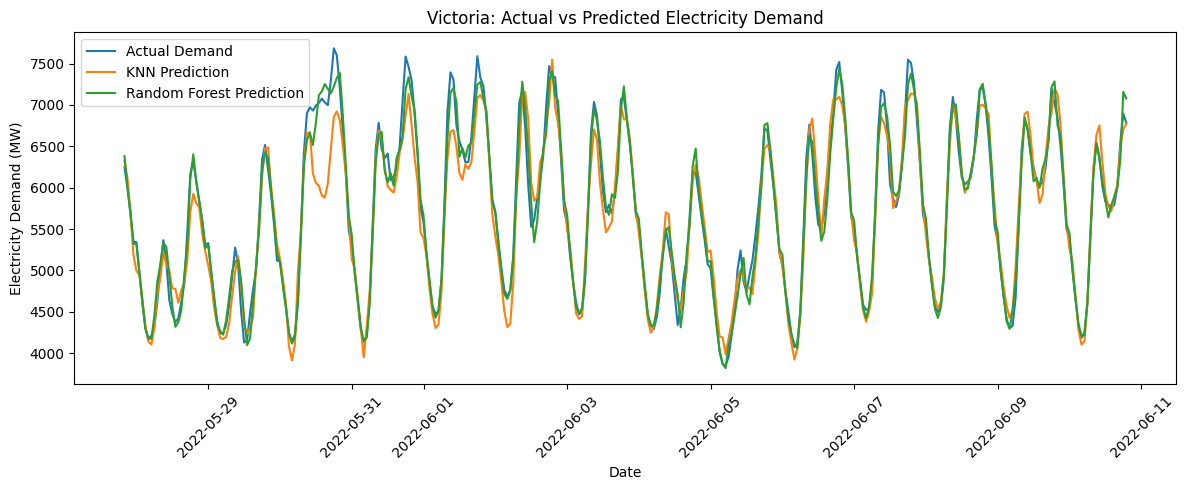

In [23]:
# Compare actual demand with both model predictions over the first two weeks of the test period.
hours_to_plot = 24 * 14

plt.figure(figsize=(12, 5))

plt.plot(
    test_vic["SETTLEMENTDATE"].iloc[:hours_to_plot],
    y_test_vic.iloc[:hours_to_plot],
    label="Actual Demand"
)

plt.plot(
    test_vic["SETTLEMENTDATE"].iloc[:hours_to_plot],
    knn_pred_vic[:hours_to_plot],
    label="KNN Prediction"
)

plt.plot(
    test_vic["SETTLEMENTDATE"].iloc[:hours_to_plot],
    rf_pred_vic[:hours_to_plot],
    label="Random Forest Prediction"
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.title("Victoria: Actual vs Predicted Electricity Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
# Check which predictors the fitted Random Forest relied on most.
# Feature importance describes the fitted model; it should not be interpreted as proof of causation.
vic_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_vic.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(vic_feature_importance)


,Feature,Importance
6,demand_lag_1h,0.897227
1,hour_cos,0.060917
0,hour_sin,0.011220
8,demand_lag_168h,0.008919
5,month_cos,0.008146
7,demand_lag_24h,0.004029
9,rrp_lag_1h,0.003110
10,rrp_lag_24h,0.002421
4,month_sin,0.001757
2,day_sin,0.001600


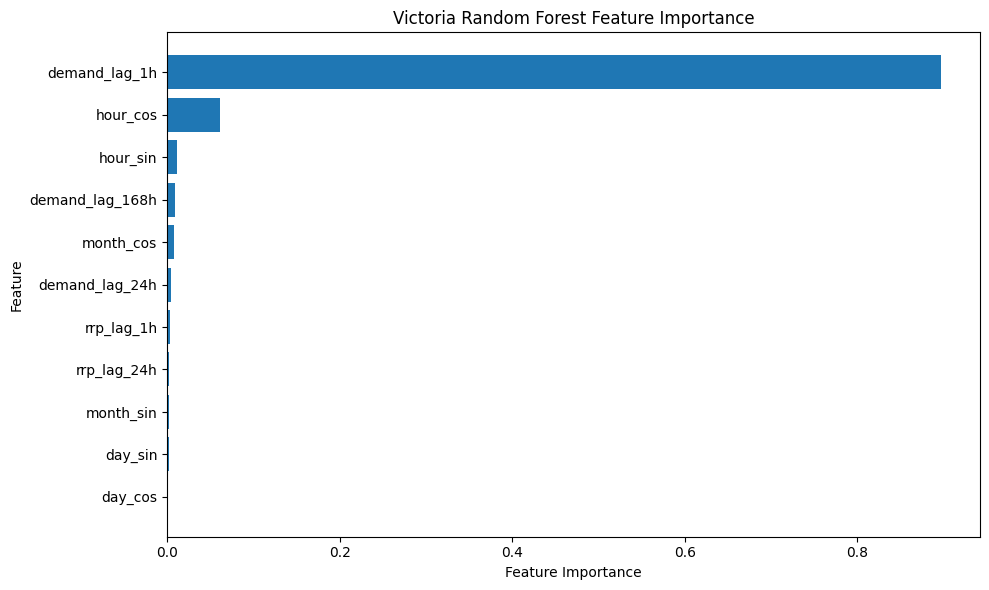

In [25]:
# Plot the feature importance values with the strongest predictor at the top.
plt.figure(figsize=(10, 6))

plt.barh(
    vic_feature_importance["Feature"],
    vic_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Victoria Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [26]:
# Inspect the largest Random Forest misses instead of relying only on average performance measures.
vic_rf_errors = pd.DataFrame({
    "SETTLEMENTDATE": test_vic["SETTLEMENTDATE"].values,
    "Actual": y_test_vic.values,
    "Predicted": rf_pred_vic
})

vic_rf_errors["Absolute_Error"] = abs(
    vic_rf_errors["Actual"] -
    vic_rf_errors["Predicted"]
)

display(
    vic_rf_errors.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)


,SETTLEMENTDATE,Actual,Predicted,Absolute_Error
3253,2022-10-10 09:00:00,5041.371667,6073.333766,1031.962100
5640,2023-01-17 20:00:00,7197.296667,8219.457544,1022.160878
1286,2022-07-20 10:00:00,7259.238333,8106.395465,847.157132
5897,2023-01-28 13:00:00,4880.521667,4035.272831,845.248836
3254,2022-10-10 10:00:00,4060.091667,4891.369303,831.277636
3185,2022-10-07 13:00:00,4237.440000,5065.934685,828.494685
1308,2022-07-21 08:00:00,7522.563333,6703.643633,818.919701
3469,2022-10-19 09:00:00,4297.737500,5066.460452,768.722952
7719,2023-04-14 11:00:00,3588.743333,4326.879641,738.136308
4578,2022-12-04 14:00:00,4391.296667,3655.010594,736.286073


# New South Wales Electricity Demand Analysis

## Data loading and cleaning


In [27]:
# Find all monthly NSW CSV files and keep them in date order.
nsw_folder = Path("NSW")
nsw_files = sorted(nsw_folder.glob("*.csv"))

print("Number of NSW files:", len(nsw_files))
print(nsw_files[:5])


Number of NSW files: 66
[PosixPath('NSW/PRICE_AND_DEMAND_201801_NSW1.csv'), PosixPath('NSW/PRICE_AND_DEMAND_201802_NSW1.csv'), PosixPath('NSW/PRICE_AND_DEMAND_201803_NSW1.csv'), PosixPath('NSW/PRICE_AND_DEMAND_201804_NSW1.csv'), PosixPath('NSW/PRICE_AND_DEMAND_201805_NSW1.csv')]


In [28]:
# Combine all monthly NSW files. The source structure was already checked using the Victoria files.
nsw_dataframes = []

for file in nsw_files:
    df = pd.read_csv(file)
    nsw_dataframes.append(df)

nsw = pd.concat(nsw_dataframes, ignore_index=True)

print("Combined NSW shape:", nsw.shape)
display(nsw.head())


Combined NSW shape: (248592, 5)


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2018/01/01 00:30:00,6912.25,91.86,TRADE
1,NSW1,2018/01/01 01:00:00,6745.63,88.83,TRADE
2,NSW1,2018/01/01 01:30:00,6466.06,73.62,TRADE
3,NSW1,2018/01/01 02:00:00,6279.80,71.49,TRADE
4,NSW1,2018/01/01 02:30:00,6177.31,69.27,TRADE


In [29]:
# Convert settlement time to datetime and sort the records from earliest to latest.
nsw["SETTLEMENTDATE"] = pd.to_datetime(nsw["SETTLEMENTDATE"])
nsw = nsw.sort_values("SETTLEMENTDATE").reset_index(drop=True)

print(nsw.dtypes)


REGION                       str
SETTLEMENTDATE    datetime64[us]
TOTALDEMAND              float64
RRP                      float64
PERIODTYPE                   str
dtype: object


In [30]:
# Run the same data-quality checks used for Victoria.
print("Shape:", nsw.shape)

print("\nMissing values:")
print(nsw.isnull().sum())

print("\nDuplicate rows:")
print(nsw.duplicated().sum())

print("\nUnique REGION values:")
print(nsw["REGION"].value_counts())

print("\nUnique PERIODTYPE values:")
print(nsw["PERIODTYPE"].value_counts())


Shape: (248592, 5)

Missing values:
REGION            0
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
PERIODTYPE        0
dtype: int64

Duplicate rows:
0

Unique REGION values:
REGION
NSW1    248592
Name: count, dtype: int64

Unique PERIODTYPE values:
PERIODTYPE
TRADE    248592
Name: count, dtype: int64


In [31]:
# Review the range and distribution of NSW demand and price values.
display(nsw[["TOTALDEMAND", "RRP"]].describe())


,TOTALDEMAND,RRP
count,248592.000000,248592.000000
mean,7609.351612,128.619204
std,1270.924160,289.366592
min,3957.320000,-1000.000000
25%,6682.177500,59.950000
50%,7470.850000,89.010000
75%,8324.510000,144.410000
max,13700.900000,15500.000000


In [32]:
# Check the time gap between NSW observations.
time_differences_nsw = nsw["SETTLEMENTDATE"].diff()

print(time_differences_nsw.value_counts().head(10))


SETTLEMENTDATE
0 days 00:05:00    182880
0 days 00:30:00     65711
Name: count, dtype: int64


In [33]:
# Locate the change in recording frequency in the NSW source data.
nsw["TIME_DIFF"] = nsw["SETTLEMENTDATE"].diff()

nsw_change_points = nsw[
    nsw["TIME_DIFF"] != nsw["TIME_DIFF"].shift()
][["SETTLEMENTDATE", "TIME_DIFF"]]

display(nsw_change_points.tail(10))


,SETTLEMENTDATE,TIME_DIFF
0,2018-01-01 00:30:00,NaT
1,2018-01-01 01:00:00,0 days 00:30:00
65712,2021-10-01 00:05:00,0 days 00:05:00


In [34]:
# Remove the temporary time-difference column after the check is complete.
nsw = nsw.drop(columns=["TIME_DIFF"])


In [35]:
# Convert NSW to the same hourly frequency used for Victoria so the two analyses are comparable.
nsw_hourly = (
    nsw.set_index("SETTLEMENTDATE")[["TOTALDEMAND", "RRP"]]
       .resample("1h", closed="right", label="right")
       .mean()
       .dropna()
       .reset_index()
)

print("Original NSW shape:", nsw.shape)
print("Hourly NSW shape:", nsw_hourly.shape)

display(nsw_hourly.head())


Original NSW shape: (248592, 5)
Hourly NSW shape: (48096, 3)


,SETTLEMENTDATE,TOTALDEMAND,RRP
0,2018-01-01 01:00:00,6828.940,90.345
1,2018-01-01 02:00:00,6372.930,72.555
2,2018-01-01 03:00:00,6113.870,68.855
3,2018-01-01 04:00:00,6000.490,68.625
4,2018-01-01 05:00:00,5957.965,67.310


In [36]:
# Confirm that NSW now contains a complete hourly sequence.
print("Hourly date range:")
print(nsw_hourly["SETTLEMENTDATE"].min())
print(nsw_hourly["SETTLEMENTDATE"].max())

print("\nMissing values:")
print(nsw_hourly.isnull().sum())

print("\nTime interval check:")
print(nsw_hourly["SETTLEMENTDATE"].diff().value_counts().head())


Hourly date range:
2018-01-01 01:00:00
2023-06-28 00:00:00

Missing values:
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
dtype: int64

Time interval check:
SETTLEMENTDATE
0 days 01:00:00    48095
Name: count, dtype: int64


## Feature engineering and train/test split


In [37]:
# Create the same time and lagged predictors used for Victoria.
nsw_model = nsw_hourly.copy()

hour = nsw_model["SETTLEMENTDATE"].dt.hour
day_of_week = nsw_model["SETTLEMENTDATE"].dt.dayofweek
month = nsw_model["SETTLEMENTDATE"].dt.month

nsw_model["hour_sin"] = np.sin(2 * np.pi * hour / 24)
nsw_model["hour_cos"] = np.cos(2 * np.pi * hour / 24)

nsw_model["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
nsw_model["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)

nsw_model["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
nsw_model["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

nsw_model["demand_lag_1h"] = nsw_model["TOTALDEMAND"].shift(1)
nsw_model["demand_lag_24h"] = nsw_model["TOTALDEMAND"].shift(24)
nsw_model["demand_lag_168h"] = nsw_model["TOTALDEMAND"].shift(168)

nsw_model["rrp_lag_1h"] = nsw_model["RRP"].shift(1)
nsw_model["rrp_lag_24h"] = nsw_model["RRP"].shift(24)

nsw_model = nsw_model.dropna().reset_index(drop=True)

print("NSW model dataset shape:", nsw_model.shape)
print("\nMissing values:")
print(nsw_model.isnull().sum())

display(nsw_model.head())


NSW model dataset shape: (47928, 14)

Missing values:
SETTLEMENTDATE     0
TOTALDEMAND        0
RRP                0
hour_sin           0
hour_cos           0
day_sin            0
day_cos            0
month_sin          0
month_cos          0
demand_lag_1h      0
demand_lag_24h     0
demand_lag_168h    0
rrp_lag_1h         0
rrp_lag_24h        0
dtype: int64


,SETTLEMENTDATE,TOTALDEMAND,RRP,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,demand_lag_1h,demand_lag_24h,demand_lag_168h,rrp_lag_1h,rrp_lag_24h
0,2018-01-08 01:00:00,7504.415,75.630,0.258819,0.965926,0.0,1.0,0.0,1.0,7988.050,7315.745,6828.940,62.740,65.190
1,2018-01-08 02:00:00,6898.470,55.855,0.500000,0.866025,0.0,1.0,0.0,1.0,7504.415,6792.415,6372.930,75.630,55.580
2,2018-01-08 03:00:00,6736.180,54.760,0.707107,0.707107,0.0,1.0,0.0,1.0,6898.470,6538.865,6113.870,55.855,54.660
3,2018-01-08 04:00:00,6790.990,54.985,0.866025,0.500000,0.0,1.0,0.0,1.0,6736.180,6413.245,6000.490,54.760,54.505
4,2018-01-08 05:00:00,7046.920,58.525,0.965926,0.258819,0.0,1.0,0.0,1.0,6790.990,6363.945,5957.965,54.985,52.115


In [38]:
# Apply the same chronological 80/20 split used for Victoria.
split_index_nsw = int(len(nsw_model) * 0.80)

train_nsw = nsw_model.iloc[:split_index_nsw]
test_nsw = nsw_model.iloc[split_index_nsw:]

X_train_nsw = train_nsw[features]
y_train_nsw = train_nsw[target]

X_test_nsw = test_nsw[features]
y_test_nsw = test_nsw[target]

print("Training observations:", len(train_nsw))
print("Testing observations:", len(test_nsw))

print("\nTraining period:")
print(train_nsw["SETTLEMENTDATE"].min())
print("to")
print(train_nsw["SETTLEMENTDATE"].max())

print("\nTesting period:")
print(test_nsw["SETTLEMENTDATE"].min())
print("to")
print(test_nsw["SETTLEMENTDATE"].max())


Training observations: 38342
Testing observations: 9586

Training period:
2018-01-08 01:00:00
to
2022-05-24 14:00:00

Testing period:
2022-05-24 15:00:00
to
2023-06-28 00:00:00


## KNN Regression


In [39]:
# Scale NSW predictors using training data only before applying KNN.
scaler_nsw = StandardScaler()

X_train_nsw_scaled = scaler_nsw.fit_transform(X_train_nsw)
X_test_nsw_scaled = scaler_nsw.transform(X_test_nsw)

print("Training shape:", X_train_nsw_scaled.shape)
print("Testing shape:", X_test_nsw_scaled.shape)


Training shape: (38342, 11)
Testing shape: (9586, 11)


In [40]:
# Test the same K values used for Victoria so the tuning approach remains consistent.
tscv_nsw = TimeSeriesSplit(n_splits=5)
k_values = [3, 5, 7, 9, 11, 15]

knn_validation_results_nsw = []

for k in k_values:
    fold_mae = []

    for train_index, val_index in tscv_nsw.split(X_train_nsw):
        X_train_fold = X_train_nsw.iloc[train_index]
        X_val_fold = X_train_nsw.iloc[val_index]

        y_train_fold = y_train_nsw.iloc[train_index]
        y_val_fold = y_train_nsw.iloc[val_index]

        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = fold_scaler.transform(X_val_fold)

        knn = KNeighborsRegressor(
            n_neighbors=k,
            weights="distance"
        )

        knn.fit(X_train_fold_scaled, y_train_fold)
        predictions = knn.predict(X_val_fold_scaled)

        fold_mae.append(
            mean_absolute_error(y_val_fold, predictions)
        )

    knn_validation_results_nsw.append({
        "K": k,
        "Mean Validation MAE": np.mean(fold_mae)
    })

knn_validation_nsw_df = pd.DataFrame(knn_validation_results_nsw)
display(knn_validation_nsw_df)


,K,Mean Validation MAE
0,3,250.884497
1,5,242.867996
2,7,239.432050
3,9,238.864090
4,11,239.097170
5,15,240.227057


In [41]:
# K=9 produced the lowest mean validation MAE for NSW.
best_k_nsw = 9

knn_nsw = KNeighborsRegressor(
    n_neighbors=best_k_nsw,
    weights="distance"
)

knn_nsw.fit(X_train_nsw_scaled, y_train_nsw)
knn_pred_nsw = knn_nsw.predict(X_test_nsw_scaled)


In [42]:
# Evaluate the final NSW KNN predictions on the held-out test period.
knn_mae_nsw = mean_absolute_error(
    y_test_nsw,
    knn_pred_nsw
)

knn_rmse_nsw = np.sqrt(
    mean_squared_error(
        y_test_nsw,
        knn_pred_nsw
    )
)

knn_r2_nsw = r2_score(
    y_test_nsw,
    knn_pred_nsw
)

print("NSW KNN Regression Results")
print("--------------------------")
print(f"MAE:  {knn_mae_nsw:.2f} MW")
print(f"RMSE: {knn_rmse_nsw:.2f} MW")
print(f"R²:   {knn_r2_nsw:.4f}")


NSW KNN Regression Results
--------------------------
MAE:  245.16 MW
RMSE: 340.47 MW
R²:   0.9373


## Random Forest Regression


In [43]:
# Test the same Random Forest settings used for Victoria.
rf_settings_nsw = [
    {"n_estimators": 100, "min_samples_leaf": 1},
    {"n_estimators": 100, "min_samples_leaf": 2},
    {"n_estimators": 200, "min_samples_leaf": 1},
    {"n_estimators": 200, "min_samples_leaf": 2},
    {"n_estimators": 200, "min_samples_leaf": 5}
]

tscv_rf_nsw = TimeSeriesSplit(n_splits=5)
rf_validation_results_nsw = []

for settings in rf_settings_nsw:
    fold_mae = []

    for train_index, val_index in tscv_rf_nsw.split(X_train_nsw):
        X_train_fold = X_train_nsw.iloc[train_index]
        X_val_fold = X_train_nsw.iloc[val_index]

        y_train_fold = y_train_nsw.iloc[train_index]
        y_val_fold = y_train_nsw.iloc[val_index]

        model = RandomForestRegressor(
            n_estimators=settings["n_estimators"],
            min_samples_leaf=settings["min_samples_leaf"],
            random_state=42
        )

        model.fit(X_train_fold, y_train_fold)
        predictions = model.predict(X_val_fold)

        fold_mae.append(
            mean_absolute_error(y_val_fold, predictions)
        )

    rf_validation_results_nsw.append({
        "Trees": settings["n_estimators"],
        "Min Samples Leaf": settings["min_samples_leaf"],
        "Mean Validation MAE": np.mean(fold_mae)
    })

rf_validation_nsw_df = pd.DataFrame(rf_validation_results_nsw)
display(rf_validation_nsw_df)


,Trees,Min Samples Leaf,Mean Validation MAE
0,100,1,117.443996
1,100,2,117.189315
2,200,1,116.881071
3,200,2,116.886824
4,200,5,119.404212


In [44]:
# 200 trees with a minimum leaf size of 1 produced the lowest validation MAE for NSW.
rf_nsw = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=1,
    random_state=42
)

rf_nsw.fit(X_train_nsw, y_train_nsw)
rf_pred_nsw = rf_nsw.predict(X_test_nsw)


In [45]:
# Evaluate Random Forest on the same NSW test period used for KNN.
rf_mae_nsw = mean_absolute_error(
    y_test_nsw,
    rf_pred_nsw
)

rf_rmse_nsw = np.sqrt(
    mean_squared_error(
        y_test_nsw,
        rf_pred_nsw
    )
)

rf_r2_nsw = r2_score(
    y_test_nsw,
    rf_pred_nsw
)

print("NSW Random Forest Regression Results")
print("------------------------------------")
print(f"MAE:  {rf_mae_nsw:.2f} MW")
print(f"RMSE: {rf_rmse_nsw:.2f} MW")
print(f"R²:   {rf_r2_nsw:.4f}")


NSW Random Forest Regression Results
------------------------------------
MAE:  144.11 MW
RMSE: 213.49 MW
R²:   0.9753


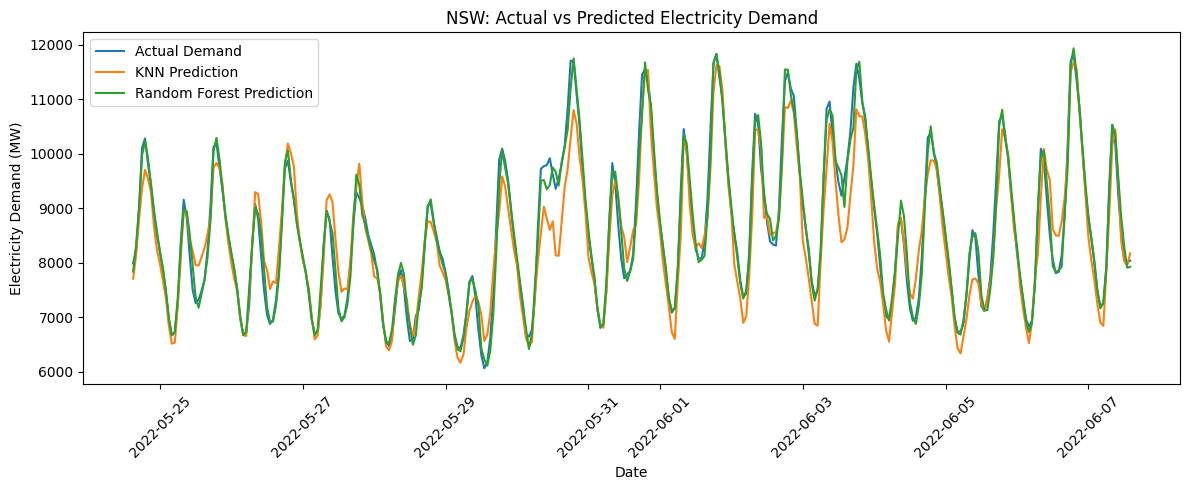

In [46]:
# Compare actual NSW demand with both model predictions over the first two weeks of the test period.
hours_to_plot = 24 * 14

plt.figure(figsize=(12, 5))

plt.plot(
    test_nsw["SETTLEMENTDATE"].iloc[:hours_to_plot],
    y_test_nsw.iloc[:hours_to_plot],
    label="Actual Demand"
)

plt.plot(
    test_nsw["SETTLEMENTDATE"].iloc[:hours_to_plot],
    knn_pred_nsw[:hours_to_plot],
    label="KNN Prediction"
)

plt.plot(
    test_nsw["SETTLEMENTDATE"].iloc[:hours_to_plot],
    rf_pred_nsw[:hours_to_plot],
    label="Random Forest Prediction"
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.title("NSW: Actual vs Predicted Electricity Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
# Check which predictors the NSW Random Forest relied on most.
nsw_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_nsw.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(nsw_feature_importance)


,Feature,Importance
6,demand_lag_1h,0.890308
1,hour_cos,0.044929
7,demand_lag_24h,0.027531
0,hour_sin,0.012277
5,month_cos,0.010093
8,demand_lag_168h,0.007421
9,rrp_lag_1h,0.001975
10,rrp_lag_24h,0.001947
2,day_sin,0.001566
4,month_sin,0.001240


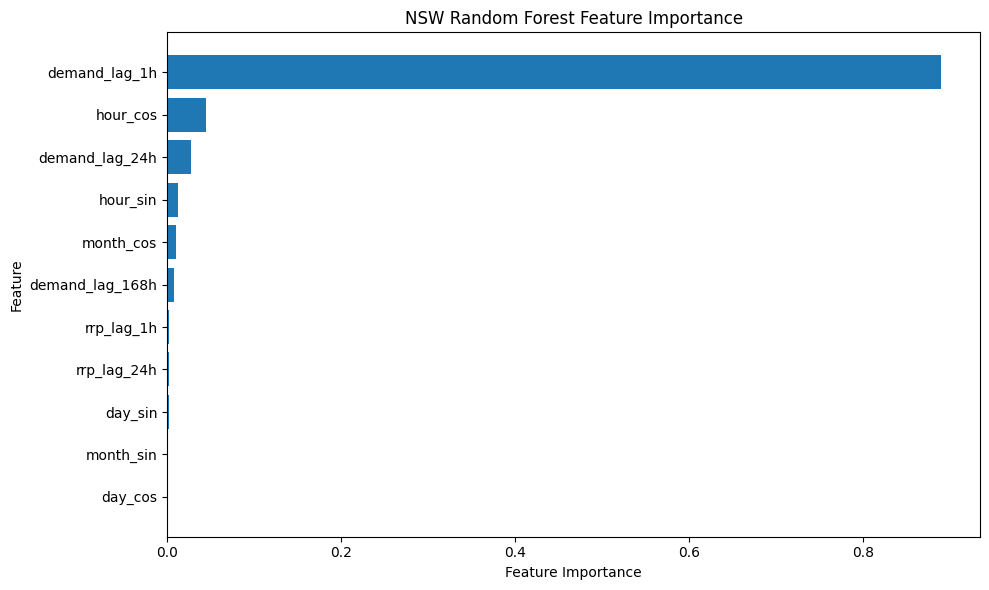

In [48]:
# Plot NSW feature importance with the strongest predictor at the top.
plt.figure(figsize=(10, 6))

plt.barh(
    nsw_feature_importance["Feature"],
    nsw_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("NSW Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [49]:
# Inspect the largest NSW Random Forest prediction errors.
nsw_rf_errors = pd.DataFrame({
    "SETTLEMENTDATE": test_nsw["SETTLEMENTDATE"].values,
    "Actual": y_test_nsw.values,
    "Predicted": rf_pred_nsw
})

nsw_rf_errors["Absolute_Error"] = abs(
    nsw_rf_errors["Actual"] -
    nsw_rf_errors["Predicted"]
)

display(
    nsw_rf_errors.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)


,SETTLEMENTDATE,Actual,Predicted,Absolute_Error
9425,2023-06-21 08:00:00,11699.574167,10542.391750,1157.182417
497,2022-06-14 08:00:00,11151.760000,10049.517600,1102.242400
9427,2023-06-21 10:00:00,10014.785000,11106.476383,1091.691383
9376,2023-06-19 07:00:00,9604.817500,8528.638396,1076.179104
3741,2022-10-27 12:00:00,6809.429167,5746.239946,1063.189221
523,2022-06-15 10:00:00,9674.722500,10658.390750,983.668250
1243,2022-07-15 10:00:00,9804.141667,10776.516737,972.375071
4914,2022-12-15 09:00:00,5838.165833,6803.911704,965.745871
7106,2023-03-16 17:00:00,11820.604167,10859.564038,961.040129
6479,2023-02-18 14:00:00,8902.819167,7945.362850,957.456317


# Final Model Comparison


In [50]:
# Put all final test metrics in one table for a direct comparison across states and models.
combined_results = pd.DataFrame({
    "State": [
        "Victoria",
        "Victoria",
        "NSW",
        "NSW"
    ],
    "Model": [
        "KNN Regression",
        "Random Forest Regression",
        "KNN Regression",
        "Random Forest Regression"
    ],
    "MAE (MW)": [
        knn_mae_vic,
        rf_mae_vic,
        knn_mae_nsw,
        rf_mae_nsw
    ],
    "RMSE (MW)": [
        knn_rmse_vic,
        rf_rmse_vic,
        knn_rmse_nsw,
        rf_rmse_nsw
    ],
    "R²": [
        knn_r2_vic,
        rf_r2_vic,
        knn_r2_nsw,
        rf_r2_nsw
    ]
})

display(combined_results)


,State,Model,MAE (MW),RMSE (MW),R²
0,Victoria,KNN Regression,176.698177,245.529792,0.934269
1,Victoria,Random Forest Regression,113.189261,162.659074,0.971152
2,NSW,KNN Regression,245.158364,340.473494,0.937280
3,NSW,Random Forest Regression,144.113421,213.487768,0.975340
